# Supplementary Jiang24 example perturbation profiles

Reproduces additional Jiang24 example response profiles for seen and unseen perturbation settings.


In [1]:
# Set to True to write image files to figures/supplement/output/.
SAVE_FIGURES = False

## Seen perturbation example


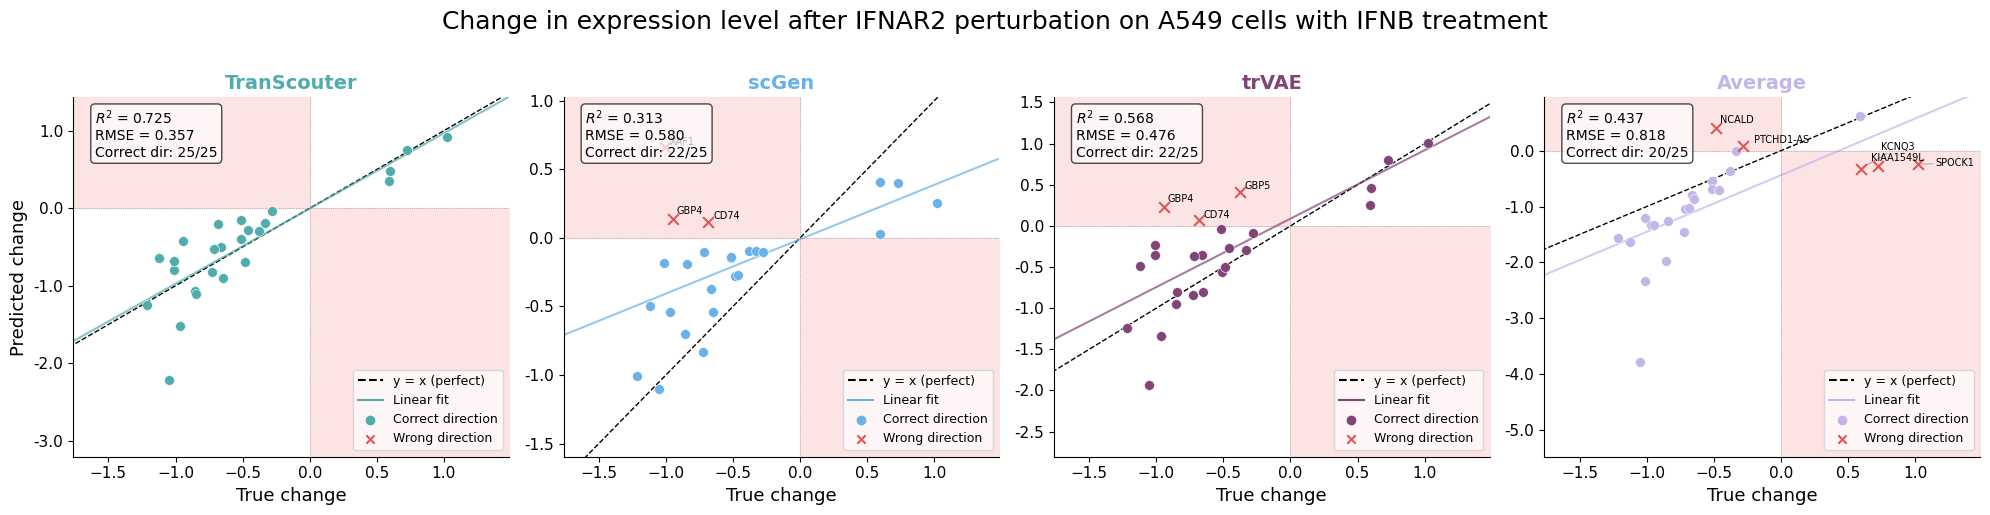

In [2]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from adjustText import adjust_text
import os
from pathlib import Path
ROOT = Path.cwd().resolve()
while not ((ROOT / "transcouter").is_dir() and (ROOT / "code").is_dir() and (ROOT / "figures").is_dir()) and ROOT.parent != ROOT:
    ROOT = ROOT.parent
if not ((ROOT / "transcouter").is_dir() and (ROOT / "code").is_dir() and (ROOT / "figures").is_dir()):
    raise RuntimeError("Run this notebook from inside the TranScouter repository")
os.chdir(ROOT)
Path("figures/main/output").mkdir(parents=True, exist_ok=True)
Path("figures/supplement/output").mkdir(parents=True, exist_ok=True)

# fmt: off
with open("results/collected/jiang/seen_pred_results.pkl", "rb") as f:
    results = pickle.load(f)
with open("data/jiang/processed/top_degs_names.pkl", "rb") as f:
    top_degs_names = pickle.load(f)

cov_pert = 'a549+IFNB_IFNAR2'
cov, pert = cov_pert.split('_')
celltype, treatment = cov.split('+')
cov_ctrl = f'{cov}_control'
degs = top_degs_names[cov_pert]

ctrl = results['Ctrl'].loc[cov_ctrl, degs]
true = results['True'].loc[cov_pert, degs] - ctrl

methods = {
    'TranScouter': results['TranScouter'].loc[cov_pert, degs] - ctrl,
    'scGen': results['scGen'].loc[cov_pert, degs] - ctrl,
    'trVAE': results['trVAE'].loc[cov_pert, degs] - ctrl,
    'Average': results['Avg'].loc[cov_pert, degs] - ctrl,
}
colors = {
    'TranScouter': '#50acad',
    'scGen': '#6ab1e9',
    'trVAE': '#814476',
    'Average': '#c3b5ea',
}

plt.rcParams.update({
    'axes.titlesize': 14,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
})

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle(
    f"Change in expression level after {pert} perturbation on "
    f"{celltype.upper()} cells with {treatment.upper()} treatment",
    fontsize=18, y=1.02,
)

# x bounds: x_min (left) gives room for top-left stats box; x_max (right) for bottom-right legend
x_min = true.values.min() * 1.45
x_max = true.values.max() * 1.45

for ax, (method, pred) in zip(axes, methods.items()):
    color = colors[method]
    correct = np.sign(pred.values) == np.sign(true.values)

    # y_max (top) gives room for top-left stats box; y_min (bottom) for bottom-right legend
    y_min = pred.values.min() * 1.45
    y_max = pred.values.max() * 1.55
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    # pink shading for wrong-direction quadrants
    ax.fill_between([x_min, 0], 0, y_max, color='#fce4e4', zorder=0)
    ax.fill_between([0, x_max], y_min, 0, color='#fce4e4', zorder=0)

    # y=x and linear fit
    diag_lim = max(abs(x_min), abs(x_max), abs(y_min), abs(y_max))
    ax.plot([-diag_lim, diag_lim], [-diag_lim, diag_lim], 'k--', linewidth=1, zorder=1)
    lr = LinearRegression().fit(true.values.reshape(-1, 1), pred.values)
    x_fit = np.linspace(x_min, x_max, 100)
    ax.plot(x_fit, lr.predict(x_fit.reshape(-1, 1)), color=color, linewidth=1.5, alpha=0.7, zorder=2)

    # scatter
    ax.scatter(true[correct], pred[correct], color=color, marker='o', s=50, edgecolors='white', linewidths=0.4, zorder=3)
    ax.scatter(true[~correct], pred[~correct], color='#e05555', marker='x', s=60, linewidths=1.5, zorder=3)

    # gene labels for wrong predictions only, non-overlapping
    wrong_genes = np.array(degs)[~correct]
    # print(method, wrong_genes)
    texts = [ax.text(true[gene], pred[gene], gene, fontsize=7) for gene in wrong_genes]
    adjust_text(texts, ax=ax,
                x=true[wrong_genes].values, y=pred[wrong_genes].values,
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

    # stats box — top-left; y_max and x_min are padded to keep this clear of data
    r2 = pearsonr(true.values, pred.values)[0] ** 2
    rmse = np.sqrt(mean_squared_error(true.values, pred.values))
    n_correct = correct.sum()
    ax.text(0.05, 0.97,
            f"$R^2$ = {r2:.3f}\nRMSE = {rmse:.3f}\nCorrect dir: {n_correct}/{len(degs)}",
            transform=ax.transAxes, fontsize=10, va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

    ax.axhline(0, color='gray', linewidth=0.5, linestyle=':')
    ax.axvline(0, color='gray', linewidth=0.5, linestyle=':')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}'))
    ax.set_xlabel('True change')
    ax.set_ylabel('Predicted change' if ax == axes[0] else '')
    ax.set_title(method, color=color, fontweight='bold')

    handles = [
        plt.Line2D([0], [0], linestyle='--', color='black', label='y = x (perfect)'),
        plt.Line2D([0], [0], color=color, label='Linear fit'),
        plt.scatter([], [], color=color, marker='o', label='Correct direction'),
        plt.scatter([], [], color='#e05555', marker='x', label='Wrong direction'),
    ]
    ax.legend(handles=handles, loc='lower right', fontsize=9, framealpha=0.7)
plt.tight_layout()
filename = f"figures/supplement/output/Examp_{pert}.png"
if globals().get("SAVE_FIGURES", False):
    fig.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()


## Unseen perturbation example


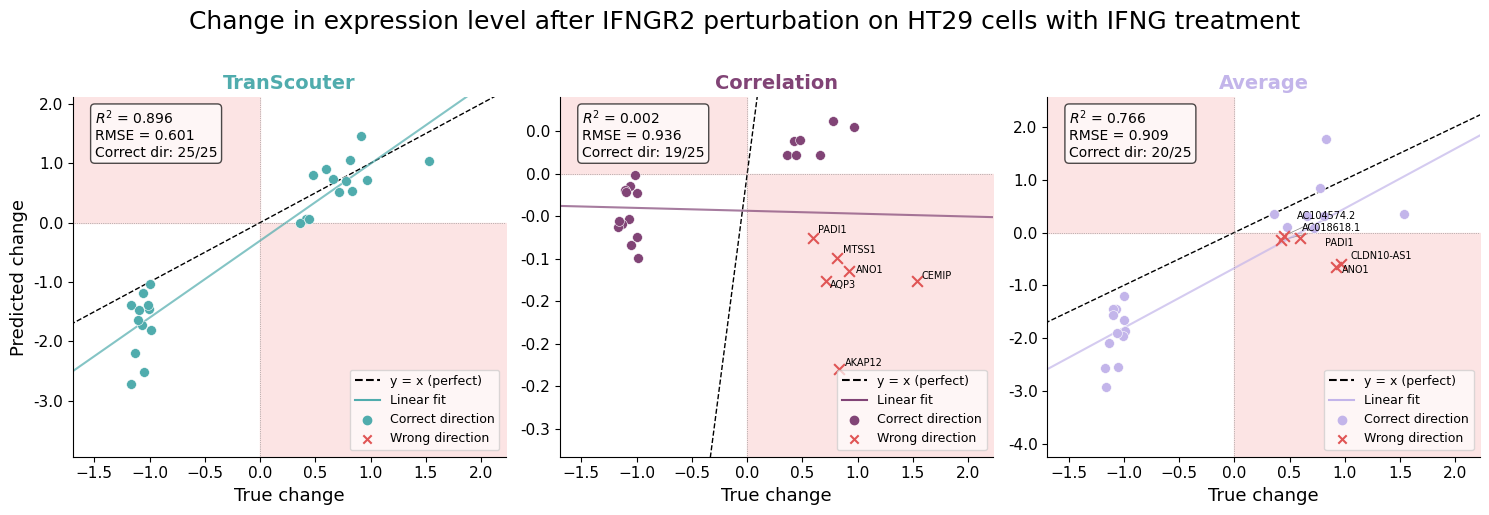

In [3]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from adjustText import adjust_text
import os
from pathlib import Path
ROOT = Path.cwd().resolve()
while not ((ROOT / "transcouter").is_dir() and (ROOT / "code").is_dir() and (ROOT / "figures").is_dir()) and ROOT.parent != ROOT:
    ROOT = ROOT.parent
if not ((ROOT / "transcouter").is_dir() and (ROOT / "code").is_dir() and (ROOT / "figures").is_dir()):
    raise RuntimeError("Run this notebook from inside the TranScouter repository")
os.chdir(ROOT)
Path("figures/main/output").mkdir(parents=True, exist_ok=True)
Path("figures/supplement/output").mkdir(parents=True, exist_ok=True)

# fmt: off
with open("results/collected/jiang/unseen_pred_results.pkl", "rb") as f:
    results = pickle.load(f)
with open("data/jiang/processed/top_degs_names.pkl", "rb") as f:
    top_degs_names = pickle.load(f)

cov_pert = 'ht29+IFNG_IFNGR2'
cov, pert = cov_pert.split('_')
celltype, treatment = cov.split('+')
cov_ctrl = f'{cov}_control'
degs = top_degs_names[cov_pert]

ctrl = results['Ctrl'].loc[cov_ctrl, degs]
true = results['True'].loc[cov_pert, degs] - ctrl

methods = {
    'TranScouter': results['TranScouter'].loc[cov_pert, degs] - ctrl,
    'Correlation': results['Correlation'].loc[cov_pert, degs] - ctrl,
    'Average':     results['Avg'].loc[cov_pert, degs] - ctrl,
}
colors = {
    'TranScouter': '#50acad',
    'Correlation': '#814476',
    'Average':     '#c3b5ea',
}

plt.rcParams.update({
    'axes.titlesize': 14,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
})

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    f"Change in expression level after {pert} perturbation on "
    f"{celltype.upper()} cells with {treatment.upper()} treatment",
    fontsize=18, y=1.02,
)

corner_pad = 1.45
x_min = true.values.min() * corner_pad
x_max = true.values.max() * corner_pad

for ax, (method, pred) in zip(axes, methods.items()):
    color = colors[method]
    correct = np.sign(pred.values) == np.sign(true.values)

    y_min = pred.values.min() * corner_pad
    y_max = pred.values.max() * corner_pad
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    # pink shading for wrong-direction quadrants
    ax.fill_between([x_min, 0], 0, y_max, color='#fce4e4', zorder=0)
    ax.fill_between([0, x_max], y_min, 0, color='#fce4e4', zorder=0)

    # y=x diagonal and linear fit
    diag_lim = max(abs(x_min), abs(x_max), abs(y_min), abs(y_max))
    ax.plot([-diag_lim, diag_lim], [-diag_lim, diag_lim], 'k--', linewidth=1, zorder=1)
    lr = LinearRegression().fit(true.values.reshape(-1, 1), pred.values)
    x_fit = np.linspace(x_min, x_max, 100)
    ax.plot(x_fit, lr.predict(x_fit.reshape(-1, 1)), color=color, linewidth=1.5, alpha=0.7, zorder=2)

    # scatter
    ax.scatter(true[correct], pred[correct], color=color, marker='o', s=50, edgecolors='white', linewidths=0.4, zorder=3)
    ax.scatter(true[~correct], pred[~correct], color='#e05555', marker='x', s=60, linewidths=1.5, zorder=3)

    # gene labels for wrong predictions only, non-overlapping
    wrong_genes = np.array(degs)[~correct]
    # print(method, wrong_genes)
    texts = [ax.text(true[gene], pred[gene], gene, fontsize=7) for gene in wrong_genes]
    adjust_text(texts, ax=ax,
                x=true[wrong_genes].values, y=pred[wrong_genes].values,
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

    # stats box top-left
    r2 = pearsonr(true.values, pred.values)[0] ** 2
    rmse = np.sqrt(mean_squared_error(true.values, pred.values))
    n_correct = correct.sum()
    ax.text(0.05, 0.97,
            f"$R^2$ = {r2:.3f}\nRMSE = {rmse:.3f}\nCorrect dir: {n_correct}/{len(degs)}",
            transform=ax.transAxes, fontsize=10, va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

    ax.axhline(0, color='gray', linewidth=0.5, linestyle=':')
    ax.axvline(0, color='gray', linewidth=0.5, linestyle=':')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}'))
    ax.set_xlabel('True change')
    ax.set_ylabel('Predicted change' if ax == axes[0] else '')
    ax.set_title(method, color=color, fontweight='bold')

    handles = [
        plt.Line2D([0], [0], linestyle='--', color='black', label='y = x (perfect)'),
        plt.Line2D([0], [0], color=color, label='Linear fit'),
        plt.scatter([], [], color=color, marker='o', label='Correct direction'),
        plt.scatter([], [], color='#e05555', marker='x', label='Wrong direction'),
    ]
    ax.legend(handles=handles, loc='lower right', fontsize=9, framealpha=0.7)

plt.tight_layout()
filename = f"figures/supplement/output/Examp_{pert}.png"
if globals().get("SAVE_FIGURES", False):
    fig.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()
